# Cardiomegaly Classifier — MobileNetV2

Binary classification of chest X-rays for cardiomegaly detection using a fine-tuned MobileNetV2 backbone.

**Pipeline overview:**
1. Imports & Configuration
2. Data Loading & Splitting
3. Transforms & Dataset Pipeline
4. Model Definition
5. Training Utilities (epoch runner, metrics, thresholds)
6. Training (frozen head → fine-tune backbone)
7. TTA Evaluation & Threshold Selection
8. Visualisation (ROC Curves)
9. Submission

## 1 · Imports & Configuration

In [91]:
import os
import copy
import json
import math
import random
from dataclasses import dataclass
from typing import Optional, Tuple, List

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix

In [ ]:
# ---------------------------------------------------------------------------
# Configuration — edit paths here before running
# ---------------------------------------------------------------------------
@dataclass
class Config:
    # ── Data paths ──────────────────────────────────────────────────────────
    csv_path:              str = "../train_val 2/train_val.csv"
    image_dir:             str = "../train_val 2/images"
    submission_test_dir:   str = "../train_val 2/test_images"   # set if you have unlabelled test images
    output_dir:            str = "results"

    # ── Reproducibility ─────────────────────────────────────────────────────
    seed:                  int = 42

    # ── Image / loader ──────────────────────────────────────────────────────
    img_size:              int = 224
    batch_size:            int = 32
    num_workers:           int = 0   # macOS + Jupyter: spawn-based multiprocessing doesn't work in notebooks

    # ── Train / val / test split ─────────────────────────────────────────────
    val_size:              float = 0.15
    test_size:             float = 0.15

    # ── Training schedule ────────────────────────────────────────────────────
    frozen_epochs:         int   = 3
    finetune_epochs:       int   = 10

    # ── Optimiser ────────────────────────────────────────────────────────────
    head_lr:               float = 5e-4
    backbone_lr:           float = 3e-5
    weight_decay:          float = 1e-4
    dropout:               float = 0.20
    early_stop_patience:   int   = 6

    # ── Dataset normalisation ─────────────────────────────────────────────────
    use_dataset_stats:     bool           = True
    stats_sample_size:     Optional[int]  = 1200

    # ── Clinical targets ──────────────────────────────────────────────────────
    target_sensitivity:    float = 0.90
    target_specificity:    float = 0.90

    # ── Device ────────────────────────────────────────────────────────────────
    device: str = (
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available()
        else "cpu"
    )


CFG = Config()
os.makedirs(CFG.output_dir, exist_ok=True)


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    elif torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


set_seed(CFG.seed)

print("Device :", CFG.device)
print("Results:", CFG.output_dir)

Device : mps
Results: results


## 2 · Data Loading & Splitting

In [93]:
LABEL_MAP = {"Cardiomegaly": 1, "No Finding": 0}


def load_labels(csv_path: str, image_dir: str) -> pd.DataFrame:
    """Read the CSV, map text labels to binary, resolve image paths, drop missing files.

    Expected columns: 'Image Index', 'Finding Labels'
    Label values   : 'Cardiomegaly' → 1  |  'No Finding' → 0
    """
    df = pd.read_csv(csv_path)

    required_cols = ["Image Index", "Finding Labels"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df[["Image Index", "Finding Labels"]].copy()
    df.columns = ["image_name", "label_raw"]
    df["image_name"] = df["image_name"].astype(str).str.strip()

    # Map text labels → binary; unknown values become NaN
    df["label"] = df["label_raw"].map(LABEL_MAP)
    unknown = df["label"].isna().sum()
    if unknown:
        unseen = df.loc[df["label"].isna(), "label_raw"].unique().tolist()
        print(f"Warning: {unknown} rows with unknown labels {unseen} — skipped.")

    df = df.dropna(subset=["label"]).copy()
    df["label"] = df["label"].astype(int)

    df["image_path"] = df["image_name"].apply(lambda x: os.path.join(image_dir, x))

    missing_count = (~df["image_path"].apply(os.path.exists)).sum()
    if missing_count:
        print(f"Warning: {missing_count} images not found on disk — skipped.")

    df = df[df["image_path"].apply(os.path.exists)].copy()
    df = df.drop_duplicates(subset=["image_name"]).reset_index(drop=True)

    if len(df) == 0:
        raise ValueError("No valid labelled images found.")

    print(f"Loaded {len(df)} rows")
    print(df["label"].value_counts().sort_index().rename({0: "No Finding", 1: "Cardiomegaly"}))
    return df


def split_dataframe(
    df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Stratified train / val / test split."""
    train_df, temp_df = train_test_split(
        df,
        test_size=CFG.val_size + CFG.test_size,
        stratify=df["label"],
        random_state=CFG.seed,
    )
    rel_test = CFG.test_size / (CFG.val_size + CFG.test_size)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=rel_test,
        stratify=temp_df["label"],
        random_state=CFG.seed,
    )
    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


def estimate_gray_mean_std(
    df: pd.DataFrame,
    sample_size: Optional[int] = 1000,
) -> Tuple[float, float]:
    """Compute per-channel mean and std from a random sample of training images."""
    sample_df = df
    if sample_size is not None and len(df) > sample_size:
        sample_df = df.sample(sample_size, random_state=CFG.seed)

    pixel_sum, pixel_sq_sum, pixel_count = 0.0, 0.0, 0
    for path in sample_df["image_path"]:
        arr = np.asarray(
            Image.open(path).convert("L").resize((CFG.img_size, CFG.img_size)),
            dtype=np.float32,
        ) / 255.0
        pixel_sum    += arr.sum()
        pixel_sq_sum += (arr ** 2).sum()
        pixel_count  += arr.size

    mean = pixel_sum / pixel_count
    std  = float(np.sqrt(max(pixel_sq_sum / pixel_count - mean ** 2, 1e-12)))
    return float(mean), std

In [94]:
full_df                      = load_labels(CFG.csv_path, CFG.image_dir)
train_df, val_df, test_df    = split_dataframe(full_df)
train_mean, train_std        = estimate_gray_mean_std(train_df, CFG.stats_sample_size)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print(f"Grayscale mean: {train_mean:.6f}  std: {train_std:.6f}")

Loaded 1578 rows
label
No Finding      858
Cardiomegaly    720
Name: count, dtype: int64
Train: 1104  Val: 237  Test: 237
Grayscale mean: 0.536137  std: 0.253105


## 3 · Transforms & Dataset Pipeline

In [95]:
def _norm_params(mean: float, std: float):
    """Return (mean, std) lists for T.Normalize, using dataset stats or ImageNet."""
    if CFG.use_dataset_stats:
        return [mean] * 3, [std] * 3
    return [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]


def make_transforms(train_mean: float, train_std: float):
    mean, std = _norm_params(train_mean, train_std)

    train_tf = T.Compose([
        T.Resize((CFG.img_size + 20, CFG.img_size + 20)),
        T.RandomCrop((CFG.img_size, CFG.img_size)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        T.RandomApply([T.ColorJitter(brightness=0.2, contrast=0.2)], p=0.4),
        T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.2),
        T.RandomApply([T.RandomAutocontrast()], p=0.3),
        T.Grayscale(num_output_channels=3),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])

    eval_tf = T.Compose([
        T.Resize((CFG.img_size, CFG.img_size)),
        T.Grayscale(num_output_channels=3),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])

    return train_tf, eval_tf


def make_tta_transforms(train_mean: float, train_std: float) -> List:
    """Three-view TTA: centre crop at three scales."""
    mean, std = _norm_params(train_mean, train_std)

    def _make(resize_to: int):
        return T.Compose([
            T.Resize((resize_to, resize_to)),
            T.CenterCrop((CFG.img_size, CFG.img_size)),
            T.Grayscale(num_output_channels=3),
            T.ToTensor(),
            T.Normalize(mean=mean, std=std),
        ])

    return [
        T.Compose([T.Resize((CFG.img_size, CFG.img_size)), T.Grayscale(num_output_channels=3), T.ToTensor(), T.Normalize(mean=mean, std=std)]),
        _make(CFG.img_size + 12),
        _make(CFG.img_size + 20),
    ]

In [96]:
class CardiomegalyDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row["image_path"]).convert("L")
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(float(row["label"]), dtype=torch.float32)
        return img, label, row["image_name"]


class SubmissionDataset(Dataset):
    """Unlabelled test images for final inference."""
    def __init__(self, image_dir: str, transform=None):
        self.image_dir  = image_dir
        self.transform  = transform
        self.image_files = sorted(
            f for f in os.listdir(image_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        fname = self.image_files[idx]
        img   = Image.open(os.path.join(self.image_dir, fname)).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, fname

In [97]:
train_tf, eval_tf = make_transforms(train_mean, train_std)

train_ds = CardiomegalyDataset(train_df, transform=train_tf)
val_ds   = CardiomegalyDataset(val_df,   transform=eval_tf)
test_ds  = CardiomegalyDataset(test_df,  transform=eval_tf)

_loader_kwargs = dict(batch_size=CFG.batch_size, num_workers=CFG.num_workers, pin_memory=False)

train_loader = DataLoader(train_ds, shuffle=True,  **_loader_kwargs)
val_loader   = DataLoader(val_ds,   shuffle=False, **_loader_kwargs)
test_loader  = DataLoader(test_ds,  shuffle=False, **_loader_kwargs)

print(f"Batches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

Batches — train: 35  val: 8  test: 8


## 4 · Model Definition

In [98]:
def build_model(dropout: float = 0.20) -> nn.Module:
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(1280, 1),
    )
    return model


def freeze_backbone(model: nn.Module) -> nn.Module:
    """Freeze all feature extractor layers; only train the classification head."""
    for p in model.features.parameters():
        p.requires_grad = False
    for p in model.classifier.parameters():
        p.requires_grad = True
    return model


def unfreeze_last_blocks(model: nn.Module, n_blocks: int = 8) -> nn.Module:
    """Unfreeze the last n_blocks of the MobileNetV2 feature extractor."""
    total = len(model.features)
    start = max(0, total - n_blocks)
    for i, block in enumerate(model.features):
        for p in block.parameters():
            p.requires_grad = (i >= start)
    for p in model.classifier.parameters():
        p.requires_grad = True
    return model

## 5 · Training Utilities

In [99]:
def run_epoch(model, loader, criterion=None, optimizer=None) -> dict:
    """Single forward pass over `loader`. Pass optimizer=None for eval mode."""
    is_train = optimizer is not None
    model.train(is_train)

    losses, all_y_true, all_y_prob, all_names = [], [], [], []

    for images, labels, names in loader:
        images = images.to(CFG.device)
        labels = labels.to(CFG.device)

        with torch.set_grad_enabled(is_train):
            logits = model(images).squeeze(1)
            loss   = criterion(logits, labels) if criterion is not None else None
            probs  = torch.sigmoid(logits)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if loss is not None:
            losses.append(loss.item())
        all_y_true.extend(labels.detach().cpu().numpy())
        all_y_prob.extend(probs.detach().cpu().numpy())
        all_names.extend(list(names))

    y_true = np.array(all_y_true, dtype=np.float32)
    y_prob = np.array(all_y_prob, dtype=np.float32)
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "loss":   float(np.mean(losses)) if losses else np.nan,
        "auc":    float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else np.nan,
        "acc":    float((y_pred == y_true).mean()),
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "names":  all_names,
    }


def run_epoch_tta(model, df: pd.DataFrame, tta_transforms) -> dict:
    """Average predictions across multiple TTA transforms."""
    all_probs, final_names, final_y_true = [], None, None

    for tf in tta_transforms:
        ds     = CardiomegalyDataset(df, transform=tf)
        loader = DataLoader(ds, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=False)
        out    = run_epoch(model, loader)
        all_probs.append(out["y_prob"])
        if final_names is None:
            final_names, final_y_true = out["names"], out["y_true"]

    mean_prob = np.mean(np.stack(all_probs), axis=0)
    mean_pred = (mean_prob >= 0.5).astype(int)

    return {
        "loss":   np.nan,
        "auc":    float(roc_auc_score(final_y_true, mean_prob)) if len(np.unique(final_y_true)) > 1 else np.nan,
        "acc":    float((mean_pred == final_y_true).mean()),
        "y_true": final_y_true,
        "y_prob": mean_prob,
        "y_pred": mean_pred,
        "names":  final_names,
    }


def predict_submission_tta(model, submission_dir: str, tta_transforms) -> dict:
    """Run TTA inference on unlabelled submission images."""
    all_probs, final_names = [], None

    for tf in tta_transforms:
        ds     = SubmissionDataset(submission_dir, transform=tf)
        loader = DataLoader(ds, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=False)

        model.eval()
        fold_probs, fold_names = [], []
        with torch.no_grad():
            for images, names in loader:
                images = images.to(CFG.device)
                probs  = torch.sigmoid(model(images).squeeze(1)).detach().cpu().numpy()
                fold_probs.extend(probs)
                fold_names.extend(list(names))

        all_probs.append(np.array(fold_probs))
        if final_names is None:
            final_names = fold_names

    return {"names": final_names, "y_prob": np.mean(np.stack(all_probs), axis=0)}

In [100]:
def compute_basic_metrics(y_true, y_prob, threshold: float) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    youden      = sensitivity + specificity - 1.0
    auc         = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan

    return dict(
        threshold=float(threshold), auc=float(auc),
        sensitivity=float(sensitivity), specificity=float(specificity),
        youden=float(youden), accuracy=float(accuracy),
        precision=float(precision),
        tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn),
    )


def find_best_threshold(y_true, y_prob, mode: str = "youden") -> Tuple[float, pd.DataFrame]:
    """Search all candidate thresholds and pick the best one for `mode`.

    mode options: 'youden' | 'target_sensitivity' | 'target_specificity'
    """
    candidates = np.concatenate(([0.0], np.unique(np.round(y_prob, 6)), [1.0]))
    tab = pd.DataFrame([compute_basic_metrics(y_true, y_prob, t) for t in candidates])

    if mode == "youden":
        best_row = tab.sort_values(["youden", "auc", "accuracy"], ascending=False).iloc[0]

    elif mode == "target_sensitivity":
        good = tab[tab["sensitivity"] >= CFG.target_sensitivity]
        best_row = (
            good.sort_values(["specificity", "youden"], ascending=False).iloc[0]
            if len(good) else
            tab.iloc[(tab["sensitivity"] - CFG.target_sensitivity).abs().argsort()].iloc[0]
        )

    elif mode == "target_specificity":
        good = tab[tab["specificity"] >= CFG.target_specificity]
        best_row = (
            good.sort_values(["sensitivity", "youden"], ascending=False).iloc[0]
            if len(good) else
            tab.iloc[(tab["specificity"] - CFG.target_specificity).abs().argsort()].iloc[0]
        )

    else:
        raise ValueError(f"Unknown mode '{mode}'. Choose: youden | target_sensitivity | target_specificity")

    return float(best_row["threshold"]), tab

In [101]:
def train_stage(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    epochs: int, stage_name: str,
) -> Tuple[nn.Module, pd.DataFrame]:
    """Run one training stage with early stopping on val AUC."""
    best_score   = -np.inf
    best_state   = None
    patience_ctr = 0
    history      = []

    for epoch in range(1, epochs + 1):
        tr  = run_epoch(model, train_loader, criterion, optimizer)
        val = run_epoch(model, val_loader,   criterion)

        score = val["acc"]
        # val["auc"] if not np.isnan(val["auc"]) else val["acc"]
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(score)   # needs a metric
            else:
                scheduler.step()        # CosineAnnealingLR etc. follow a fixed curve

        history.append({
            "stage": stage_name, "epoch": epoch,
            "train_loss": tr["loss"],  "train_auc": tr["auc"],
            "val_loss":   val["loss"], "val_auc":   val["auc"], "val_acc": val["acc"],
        })

        print(
            f"[{stage_name}] epoch {epoch:>2}/{epochs} | "
            f"train_loss={tr['loss']:.4f} | "
            f"val_loss={val['loss']:.4f} | "
            f"val_auc={val['auc']:.4f} | "
            f"val_acc={val['acc']:.4f}"
        )

        if score > best_score:
            best_score, best_state, patience_ctr = score, copy.deepcopy(model.state_dict()), 0
        else:
            patience_ctr += 1
            if patience_ctr >= CFG.early_stop_patience:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

## 6 · Training

Two-stage schedule:
- **Stage 1 (frozen):** train only the classification head for `frozen_epochs` — backbone fully frozen, CosineAnnealingLR.
- **Stage 2 (fine-tune):** unfreeze the last 12 MobileNetV2 blocks and continue for `finetune_epochs` with a lower backbone LR, CosineAnnealingLR.

**Improvements applied:**
- `pos_weight` in BCEWithLogitsLoss to account for class imbalance (favours sensitivity)
- `CosineAnnealingLR` instead of ReduceLROnPlateau — smoother LR decay, better convergence
- 12 unfrozen blocks (vs 8) — deeper fine-tuning for X-ray domain adaptation
- `batch_size=32`, `num_workers=4` — faster data loading & more stable gradients
- Stronger augmentation: HorizontalFlip, GaussianBlur, ColorJitter, larger crops

In [102]:
# Weight positive class higher to penalise missed Cardiomegaly cases more
# (ratio = No Finding / Cardiomegaly = 858 / 720 ≈ 1.19)
n_neg   = (train_df["label"] == 0).sum()
n_pos   = (train_df["label"] == 1).sum()
pos_w   = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(CFG.device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
print(f"pos_weight: {pos_w.item():.4f}  (neg={n_neg}, pos={n_pos})")

model = build_model(CFG.dropout).to(CFG.device)
print(f"Training on: {CFG.device}  |  frozen_epochs: {CFG.frozen_epochs}")

# ── Stage 1: frozen backbone ──────────────────────────────────────────────
model = freeze_backbone(model)

opt_frozen = optim.AdamW(model.classifier.parameters(), lr=CFG.head_lr, weight_decay=CFG.weight_decay)
sch_frozen = optim.lr_scheduler.CosineAnnealingLR(opt_frozen, T_max=CFG.frozen_epochs, eta_min=1e-6)

model, hist_frozen = train_stage(
    model, train_loader, val_loader,
    criterion, opt_frozen, sch_frozen,
    epochs=CFG.frozen_epochs, stage_name="frozen",
)

pos_weight: 1.1905  (neg=600, pos=504)
Training on: mps  |  frozen_epochs: 10
[frozen] epoch  1/10 | train_loss=0.7292 | val_loss=0.7387 | val_auc=0.6001 | val_acc=0.5443
[frozen] epoch  2/10 | train_loss=0.6950 | val_loss=0.7038 | val_auc=0.7059 | val_acc=0.6540
[frozen] epoch  3/10 | train_loss=0.6655 | val_loss=0.6748 | val_auc=0.7396 | val_acc=0.6414
[frozen] epoch  4/10 | train_loss=0.6385 | val_loss=0.6622 | val_auc=0.7554 | val_acc=0.6751
[frozen] epoch  5/10 | train_loss=0.6559 | val_loss=0.6530 | val_auc=0.7570 | val_acc=0.6624
[frozen] epoch  6/10 | train_loss=0.6293 | val_loss=0.6479 | val_auc=0.7613 | val_acc=0.6709
[frozen] epoch  7/10 | train_loss=0.6325 | val_loss=0.6436 | val_auc=0.7685 | val_acc=0.6793
[frozen] epoch  8/10 | train_loss=0.6434 | val_loss=0.6480 | val_auc=0.7717 | val_acc=0.6793
[frozen] epoch  9/10 | train_loss=0.6369 | val_loss=0.6482 | val_auc=0.7611 | val_acc=0.6667
[frozen] epoch 10/10 | train_loss=0.6213 | val_loss=0.6396 | val_auc=0.7756 | val_acc

In [103]:
# ── Stage 2: fine-tune last 12 blocks ────────────────────────────────────
model = unfreeze_last_blocks(model, n_blocks=12)

backbone_params = [p for p in model.features.parameters()   if p.requires_grad]
head_params     = [p for p in model.classifier.parameters() if p.requires_grad]

opt_ft = optim.AdamW(
    [
        {"params": backbone_params, "lr": CFG.backbone_lr},
        {"params": head_params,     "lr": CFG.head_lr},
    ],
    weight_decay=CFG.weight_decay,
)
sch_ft = optim.lr_scheduler.CosineAnnealingLR(opt_ft, T_max=CFG.finetune_epochs, eta_min=1e-7)

model, hist_ft = train_stage(
    model, train_loader, val_loader,
    criterion, opt_ft, sch_ft,
    epochs=CFG.finetune_epochs, stage_name="finetune",
)

[finetune] epoch  1/15 | train_loss=0.6092 | val_loss=0.5864 | val_auc=0.8506 | val_acc=0.7089
[finetune] epoch  2/15 | train_loss=0.5347 | val_loss=0.5213 | val_auc=0.8589 | val_acc=0.7511
[finetune] epoch  3/15 | train_loss=0.4875 | val_loss=0.5008 | val_auc=0.8756 | val_acc=0.7722
[finetune] epoch  4/15 | train_loss=0.4487 | val_loss=0.4740 | val_auc=0.8918 | val_acc=0.7848
[finetune] epoch  5/15 | train_loss=0.4535 | val_loss=0.4697 | val_auc=0.8865 | val_acc=0.7848
[finetune] epoch  6/15 | train_loss=0.4183 | val_loss=0.4440 | val_auc=0.9016 | val_acc=0.7848
[finetune] epoch  7/15 | train_loss=0.3817 | val_loss=0.4268 | val_auc=0.9121 | val_acc=0.8017
[finetune] epoch  8/15 | train_loss=0.3860 | val_loss=0.4380 | val_auc=0.9086 | val_acc=0.8017
[finetune] epoch  9/15 | train_loss=0.3578 | val_loss=0.4254 | val_auc=0.9150 | val_acc=0.8017
[finetune] epoch 10/15 | train_loss=0.3867 | val_loss=0.4433 | val_auc=0.9130 | val_acc=0.8186
[finetune] epoch 11/15 | train_loss=0.3499 | val_l

In [104]:
history_df = pd.concat([hist_frozen, hist_ft], ignore_index=True)
history_df.to_csv(os.path.join(CFG.output_dir, "training_history.csv"), index=False)

model_path = os.path.join(CFG.output_dir, "best_model.pth")
torch.save(model.state_dict(), model_path)
print("Saved model →", model_path)

Saved model → results/best_model.pth


## 7 · TTA Evaluation & Threshold Selection

Evaluate on validation *and* test sets using three-view TTA, then compare three threshold strategies:
- **Youden** — maximises sensitivity + specificity
- **Target sensitivity** — highest specificity at ≥ 90% sensitivity
- **Target specificity** — highest sensitivity at ≥ 90% specificity

In [105]:
tta_transforms = make_tta_transforms(train_mean, train_std)

val_out  = run_epoch_tta(model, val_df,  tta_transforms)
test_out = run_epoch_tta(model, test_df, tta_transforms)

print(f"Val  AUC (TTA): {val_out['auc']:.4f}")
print(f"Test AUC (TTA): {test_out['auc']:.4f}")

Val  AUC (TTA): 0.9190
Test AUC (TTA): 0.9142


In [106]:
thr_youden, _ = find_best_threshold(val_out["y_true"], val_out["y_prob"], mode="youden")
thr_sens,   _ = find_best_threshold(val_out["y_true"], val_out["y_prob"], mode="target_sensitivity")
thr_spec,   _ = find_best_threshold(val_out["y_true"], val_out["y_prob"], mode="target_specificity")

threshold_summary = pd.DataFrame([
    {"mode": "youden",              **compute_basic_metrics(val_out["y_true"], val_out["y_prob"], thr_youden)},
    {"mode": "target_sensitivity",  **compute_basic_metrics(val_out["y_true"], val_out["y_prob"], thr_sens)},
    {"mode": "target_specificity",  **compute_basic_metrics(val_out["y_true"], val_out["y_prob"], thr_spec)},
])[["mode", "threshold", "auc", "sensitivity", "specificity", "youden", "accuracy", "precision", "tp", "tn", "fp", "fn"]]

threshold_summary.to_csv(os.path.join(CFG.output_dir, "threshold_summary.csv"), index=False)
threshold_summary

,mode,threshold,auc,sensitivity,specificity,youden,accuracy,precision,tp,tn,fp,fn
0,youden,0.712229,0.918964,0.824074,0.852713,0.676787,0.839662,0.824074,89,110,19,19
1,target_sensitivity,0.489596,0.918964,0.925926,0.728682,0.654608,0.818565,0.740741,100,94,35,8
2,target_specificity,0.816477,0.918964,0.657407,0.906977,0.564384,0.793249,0.855422,71,117,12,37


In [107]:
best_threshold = thr_youden
print(f"Selected threshold (Youden): {best_threshold:.4f}")

val_metrics  = compute_basic_metrics(val_out["y_true"],  val_out["y_prob"],  best_threshold)
test_metrics = compute_basic_metrics(test_out["y_true"], test_out["y_prob"], best_threshold)

for name, m in [("Validation", val_metrics), ("Test", test_metrics)]:
    print(f"\n{name} metrics:")
    for k, v in m.items():
        print(f"  {k}: {v}")

with open(os.path.join(CFG.output_dir, "val_metrics_final.json"),  "w") as f:
    json.dump(val_metrics, f, indent=2)
with open(os.path.join(CFG.output_dir, "test_metrics_final.json"), "w") as f:
    json.dump(test_metrics, f, indent=2)

# Save per-image prediction files
for split_name, out in [("val", val_out), ("test", test_out)]:
    pd.DataFrame({
        "image_name": out["names"],
        "y_true":     out["y_true"].astype(int),
        "prob":       out["y_prob"],
        "pred":       (out["y_prob"] >= best_threshold).astype(int),
    }).to_csv(os.path.join(CFG.output_dir, f"{split_name}_predictions.csv"), index=False)

print("\nAll metrics and predictions saved.")

Selected threshold (Youden): 0.7122

Validation metrics:
  threshold: 0.7122290134429932
  auc: 0.9189635371805914
  sensitivity: 0.8240740740740741
  specificity: 0.8527131782945736
  youden: 0.6767872523686478
  accuracy: 0.8396624472573839
  precision: 0.8240740740740741
  tp: 89
  tn: 110
  fp: 19
  fn: 19

Test metrics:
  threshold: 0.7122290134429932
  auc: 0.9142262417456216
  sensitivity: 0.7777777777777778
  specificity: 0.8837209302325582
  youden: 0.6614987080103361
  accuracy: 0.8354430379746836
  precision: 0.8484848484848485
  tp: 84
  tn: 114
  fp: 15
  fn: 24

All metrics and predictions saved.


## 8 · Visualisation — ROC Curves

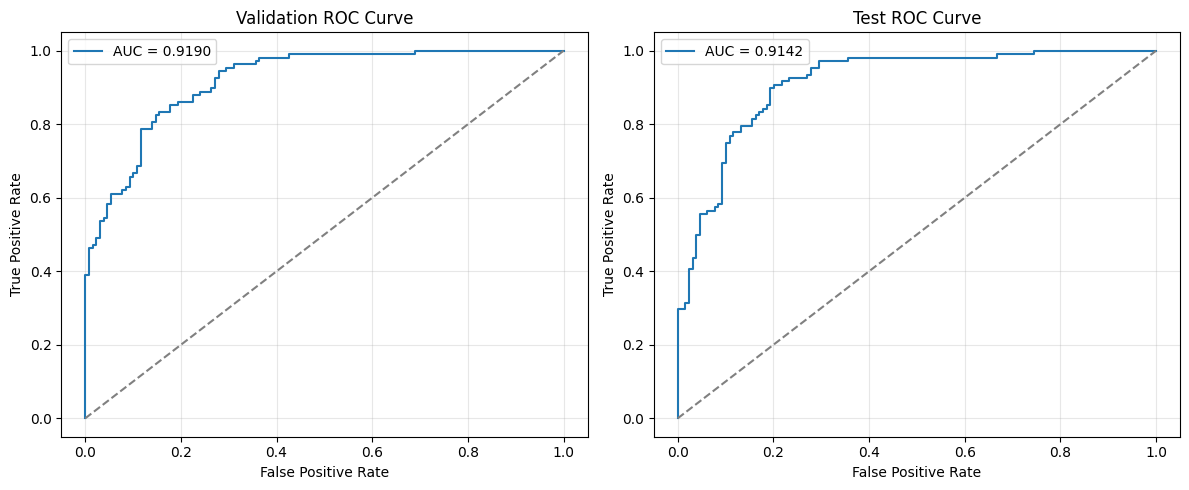

In [108]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, out, title in [
    (axes[0], val_out,  "Validation"),
    (axes[1], test_out, "Test"),
]:
    fpr, tpr, _ = roc_curve(out["y_true"], out["y_prob"])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{title} ROC Curve")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG.output_dir, "roc_curves.png"), dpi=150)
plt.show()

## 9 · Submission

In [109]:
submission_out = predict_submission_tta(model, CFG.submission_test_dir, tta_transforms)

submission_df = pd.DataFrame({
    "image_file": submission_out["names"],
    "prob":       submission_out["y_prob"],
})
submission_df["pred"] = (submission_df["prob"] >= best_threshold).astype(int)

submission_path = os.path.join(CFG.output_dir, "daily_submission.csv")
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved → {submission_path}  ({len(submission_df)} rows)")
submission_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../train_val 2/test_images'